In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dropout,
    Flatten,
    Dense
)

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("fashion-mnist_test.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.isnull().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [4]:
X = df.drop("label", axis=1).values
y = df["label"].values

In [5]:
X = X / 255.0

In [6]:
X = X.reshape(-1, 28, 28, 1)

In [7]:
y = to_categorical(y, 10)

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

c:\Users\RAJEET\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [11]:
history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5891 - loss: 1.1357 - val_accuracy: 0.7531 - val_loss: 0.6651
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7447 - loss: 0.6882 - val_accuracy: 0.7969 - val_loss: 0.5507
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7673 - loss: 0.6179 - val_accuracy: 0.8188 - val_loss: 0.5145
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7880 - loss: 0.5597 - val_accuracy: 0.8325 - val_loss: 0.4763
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8075 - loss: 0.5289 - val_accuracy: 0.8375 - val_loss: 0.4740
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8155 - loss: 0.4913 - val_accuracy: 0.8556 - val_loss: 0.4259
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8248 - loss: 0.4652 - val_accuracy: 0.8519 - val_loss: 0.4219
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8358 - loss: 0.4486 - val_accu

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8640 - loss: 0.3781

Test Accuracy: 0.8640000224113464


In [13]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [14]:
cm = confusion_matrix(true_classes,predicted_classes)
print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[146   1   2  11   0   0  31   0   1   0]
 [  0 185   0   6   1   0   0   0   0   0]
 [  1   0 164   0  31   0  16   0   0   0]
 [  6   1   1 189   4   0   4   0   0   0]
 [  0   0  12   4 171   0  17   0   0   0]
 [  0   0   0   0   0 190   0   1   2   0]
 [ 33   1  18   9  21   0 118   0   0   0]
 [  0   0   0   0   0   8   0 190   0   8]
 [  0   0   1   0   0   0   4   2 189   0]
 [  0   0   0   0   0   2   0  12   0 186]]


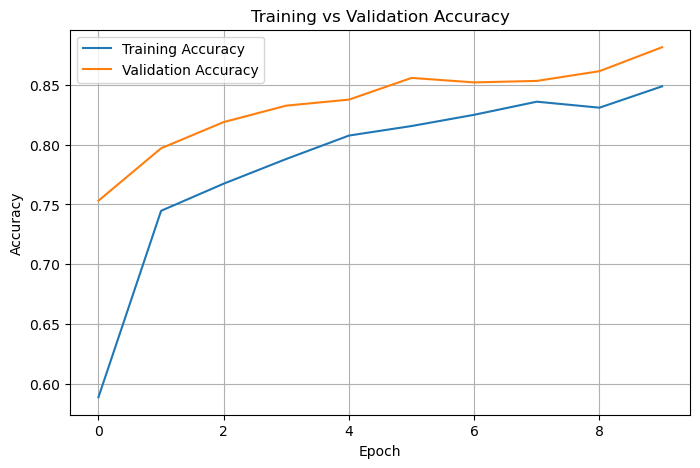

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()